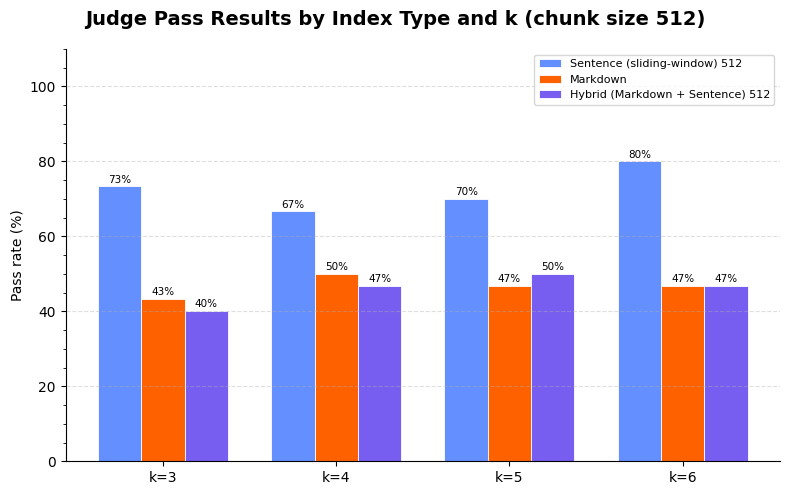

Saved: plots/1_pass_rate.png


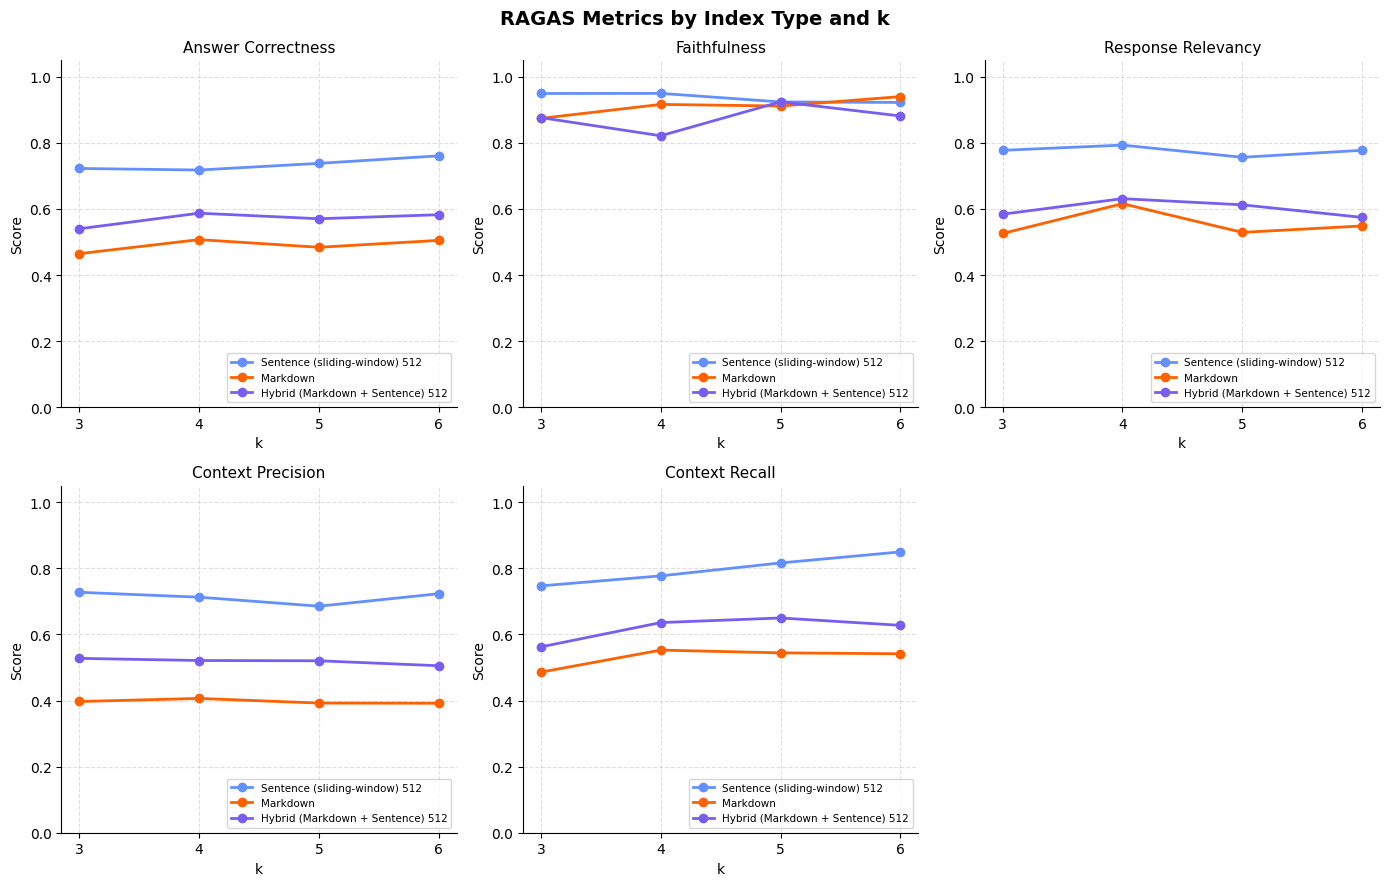

Saved: plots/2_metrics_lines.png


In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
RESULTS_DIR = Path("evals/experiments")
PLOTS_DIR   = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

K_VALUES = [3, 4, 5, 6]
METRICS  = [
    "answer_correctness",
    "faithfulness",
    "response_relevancy",
    "context_precision",
    "context_recall",
]
INDEX_LABELS = {
    "sentence":              "Sentence (sliding-window) 512",
    "markdown":              "Markdown",
    "markdown_and_sentence": "Hybrid (Markdown + Sentence) 512",
}
INDEX_COLORS = {
    "sentence":              "#648FFF",
    "markdown":              "#FE6100",
    "markdown_and_sentence": "#785EF0",
}
INDEX_TYPES = list(INDEX_LABELS.keys())

# ---------------------------------------------------------------------------
# Data loading
# ---------------------------------------------------------------------------
def build_filename(index_type: str, k: int) -> Path:
    if index_type == "sentence":
        name = f"from_index_sentence_512_k_{k}_results.csv"
    elif index_type == "markdown":
        name = f"from_index_markdown_k_{k}_results.csv"
    else:
        name = f"from_index_markdown_and_sentence_512_k_{k}_results.csv"
    return RESULTS_DIR / name


def load_all_results() -> pd.DataFrame:
    frames = []
    for index_type in INDEX_TYPES:
        for k in K_VALUES:
            path = build_filename(index_type, k)
            if not path.exists():
                print(f"[WARNING] File not found, skipping: {path}")
                continue
            df = pd.read_csv(path).dropna(subset=["question"])
            df["index_type"] = index_type
            df["k"]          = k
            frames.append(df)
    if not frames:
        raise FileNotFoundError(f"No CSVs found in '{RESULTS_DIR}'.")
    return pd.concat(frames, ignore_index=True)


def pass_stats(df: pd.DataFrame) -> pd.DataFrame:
    grp   = df.groupby(["index_type", "k"])
    stats = grp["judge_result"].apply(
        lambda s: (s.str.lower() == "pass").sum()
    ).rename("pass_count").reset_index()
    stats["total"]     = grp["judge_result"].count().values
    stats["pass_rate"] = stats["pass_count"] / stats["total"] * 100
    return stats


def metric_means(df: pd.DataFrame) -> pd.DataFrame:
    available = [m for m in METRICS if m in df.columns]
    df_filtered = df[df["answer_source"] != "absent for choice"]
    return df_filtered.groupby(["index_type", "k"])[available].mean().reset_index()

df    = load_all_results()
stats = pass_stats(df)
means = metric_means(df)

# ---------------------------------------------------------------------------
# Plot 1 — Pass rate: grouped bar chart
# ---------------------------------------------------------------------------
def plot_pass_rate(stats: pd.DataFrame, save_path: Path) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.suptitle("Judge Pass Results by Index Type and k (chunk size 512)", fontsize=14, fontweight="bold")

    bar_width = 0.25
    x = np.arange(len(K_VALUES))

    for i, idx_type in enumerate(INDEX_TYPES):
        subset = stats[stats["index_type"] == idx_type].sort_values("k")
        values = subset["pass_rate"].values
        bars = ax.bar(
            x + i * bar_width, values,
            width=bar_width,
            label=INDEX_LABELS[idx_type],
            color=INDEX_COLORS[idx_type],
            edgecolor="white", linewidth=0.6,
        )
        for bar, v in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{v:.0f}%",
                ha="center", va="bottom", fontsize=7.5,
            )

    ax.set_xticks(x + bar_width)
    ax.set_xticklabels([f"k={k}" for k in K_VALUES])
    ax.set_ylabel("Pass rate (%)")
    ax.set_ylim(0, 110)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


plot_pass_rate(stats, PLOTS_DIR / "1_pass_rate.png")

# ---------------------------------------------------------------------------
# Plot 2 — RAGAS metrics: line chart per metric
# ---------------------------------------------------------------------------
def plot_metrics_lines(means: pd.DataFrame, save_path: Path) -> None:
    available = [m for m in METRICS if m in means.columns]
    ncols = 3
    nrows = (len(available) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows), squeeze=False)
    fig.suptitle("RAGAS Metrics by Index Type and k", fontsize=14, fontweight="bold")

    for ax_idx, metric in enumerate(available):
        ax = axes[ax_idx // ncols][ax_idx % ncols]
        for idx_type in INDEX_TYPES:
            subset = means[means["index_type"] == idx_type].sort_values("k")
            ax.plot(
                subset["k"], subset[metric],
                marker="o", label=INDEX_LABELS[idx_type],
                color=INDEX_COLORS[idx_type], linewidth=2, markersize=6,
            )
        ax.set_title(metric.replace("_", " ").title(), fontsize=11)
        ax.set_xlabel("k")
        ax.set_ylabel("Score")
        ax.set_xticks(K_VALUES)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=7.5, loc="lower right")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(linestyle="--", alpha=0.4)

    for ax_idx in range(len(available), nrows * ncols):
        axes[ax_idx // ncols][ax_idx % ncols].set_visible(False)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


plot_metrics_lines(means, PLOTS_DIR / "2_metrics_lines.png")

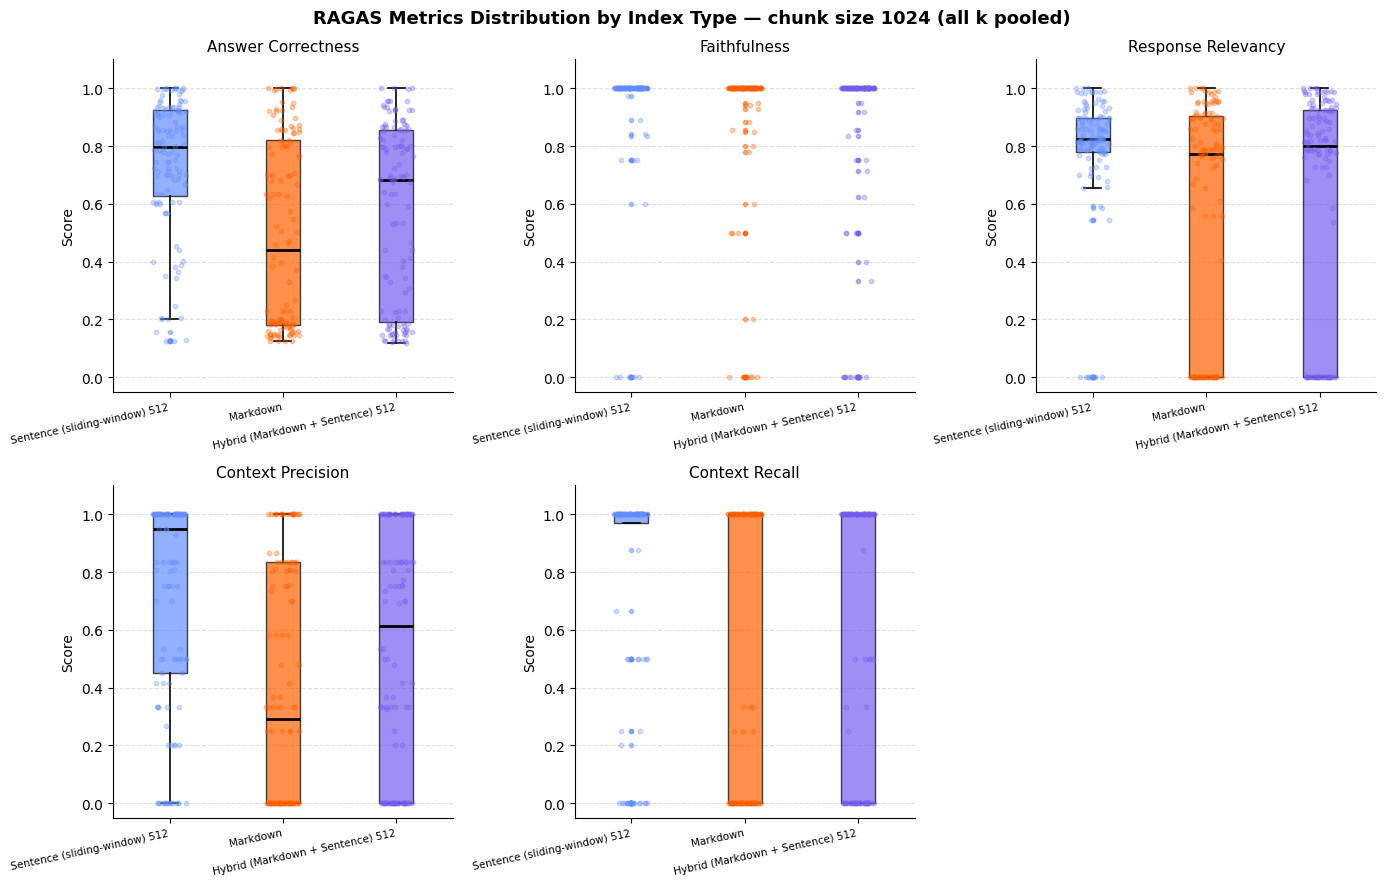

Saved: plots/3_metrics_boxplots.png


In [20]:
# ---------------------------------------------------------------------------
# Plot 3 — RAGAS metrics: box plots per index type (distribution across all k)
# ---------------------------------------------------------------------------
def plot_metrics_boxplots(df: pd.DataFrame, save_path: Path) -> None:
    available = [m for m in METRICS if m in df.columns]
    ncols = 3
    nrows = (len(available) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows), squeeze=False)
    fig.suptitle(
        "RAGAS Metrics Distribution by Index Type — chunk size 1024 (all k pooled)",
        fontsize=13, fontweight="bold",
    )

    for ax_idx, metric in enumerate(available):
        ax = axes[ax_idx // ncols][ax_idx % ncols]

        data   = [df[df["index_type"] == t][metric].dropna().values for t in INDEX_TYPES]
        labels = [INDEX_LABELS[t] for t in INDEX_TYPES]
        colors = [INDEX_COLORS[t] for t in INDEX_TYPES]

        bp = ax.boxplot(
            data,
            patch_artist=True,
            notch=False,
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            flierprops=dict(marker="o", markersize=3, linestyle="none", alpha=0.5),
        )

        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for flier, color in zip(bp["fliers"], colors):
            flier.set_markerfacecolor(color)
            flier.set_markeredgecolor(color)

        # overlay individual data points (jittered)
        for pos, (vals, color) in enumerate(zip(data, colors), start=1):
            jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(vals))
            ax.scatter(
                pos + jitter, vals,
                color=color, alpha=0.3, s=10, zorder=3,
            )

        ax.set_title(metric.replace("_", " ").title(), fontsize=11)
        ax.set_xticks(range(1, len(INDEX_TYPES) + 1))
        ax.set_xticklabels(labels, fontsize=7.5, rotation=12, ha="right")
        ax.set_ylabel("Score")
        ax.set_ylim(-0.05, 1.1)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    for ax_idx in range(len(available), nrows * ncols):
        axes[ax_idx // ncols][ax_idx % ncols].set_visible(False)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


plot_metrics_boxplots(df, PLOTS_DIR / "3_metrics_boxplots.png")

# NO ANSWARE: 512

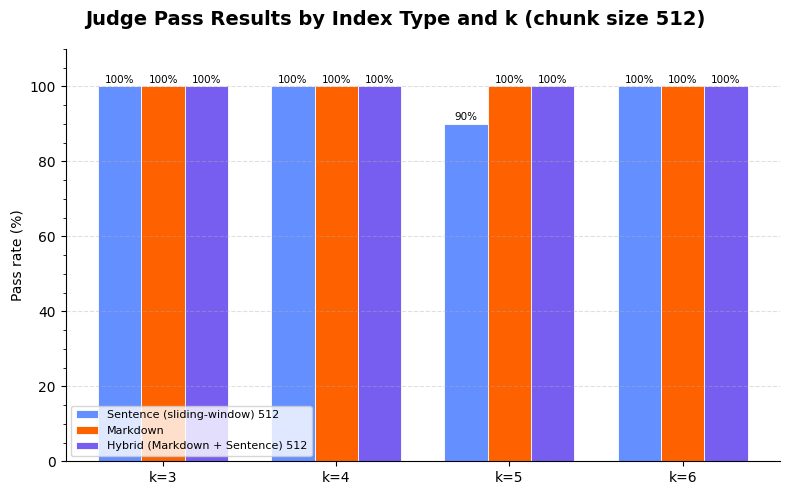

Saved: plots/1_pass_rate.png


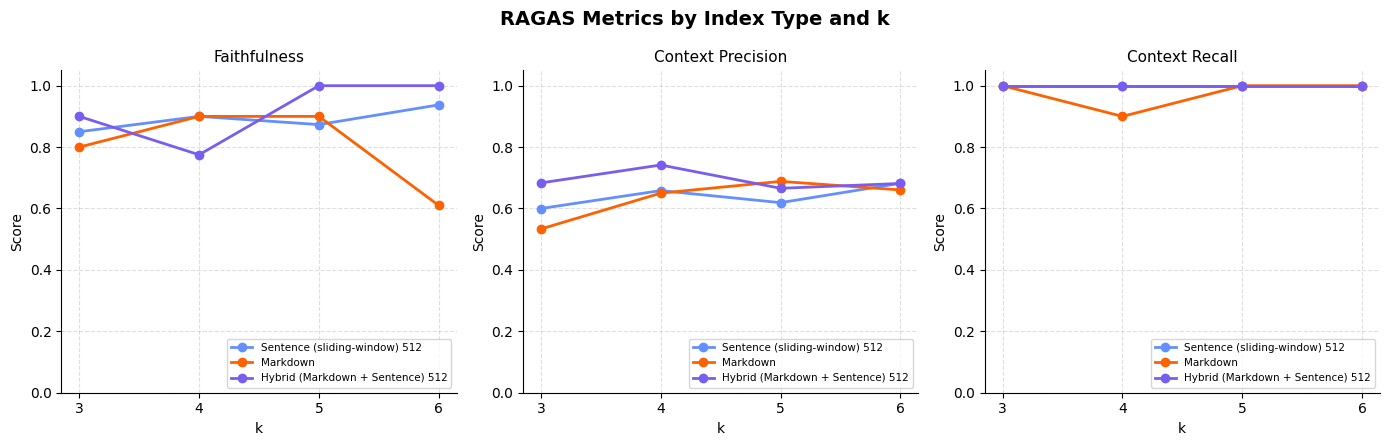

Saved: plots/2_metrics_lines.png


In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
RESULTS_DIR = Path("evals/experiments/no_answare")
PLOTS_DIR   = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

K_VALUES = [3, 4, 5, 6]
METRICS  = [
    "faithfulness",
    "context_precision",
    "context_recall",
]
INDEX_LABELS = {
    "sentence":              "Sentence (sliding-window) 512",
    "markdown":              "Markdown",
    "markdown_and_sentence": "Hybrid (Markdown + Sentence) 512",
}
INDEX_COLORS = {
    "sentence":              "#648FFF",
    "markdown":              "#FE6100",
    "markdown_and_sentence": "#785EF0",
}
INDEX_TYPES = list(INDEX_LABELS.keys())

# ---------------------------------------------------------------------------
# Data loading
# ---------------------------------------------------------------------------
def build_filename(index_type: str, k: int) -> Path:
    if index_type == "sentence":
        name = f"from_index_sentence_no_answare_512_k_{k}_results.csv"
    elif index_type == "markdown":
        name = f"from_index_markdown_no_answare_k_{k}_results.csv"
    else:
        name = f"from_index_markdown_and_sentence_no_answare_512_k_{k}_results.csv"
    return RESULTS_DIR / name


def load_all_results() -> pd.DataFrame:
    frames = []
    for index_type in INDEX_TYPES:
        for k in K_VALUES:
            path = build_filename(index_type, k)
            if not path.exists():
                print(f"[WARNING] File not found, skipping: {path}")
                continue
            df = pd.read_csv(path).dropna(subset=["question"])
            df["index_type"] = index_type
            df["k"]          = k
            frames.append(df)
    if not frames:
        raise FileNotFoundError(f"No CSVs found in '{RESULTS_DIR}'.")
    return pd.concat(frames, ignore_index=True)


def pass_stats(df: pd.DataFrame) -> pd.DataFrame:
    grp   = df.groupby(["index_type", "k"])
    stats = grp["judge_result"].apply(
        lambda s: (s.str.lower() == "pass").sum()
    ).rename("pass_count").reset_index()
    stats["total"]     = grp["judge_result"].count().values
    stats["pass_rate"] = stats["pass_count"] / stats["total"] * 100
    return stats


def metric_means(df: pd.DataFrame) -> pd.DataFrame:
    available = [m for m in METRICS if m in df.columns]
    return df.groupby(["index_type", "k"])[available].mean().reset_index()

df    = load_all_results()
stats = pass_stats(df)
means = metric_means(df)

# ---------------------------------------------------------------------------
# Plot 1 — Pass rate: grouped bar chart
# ---------------------------------------------------------------------------
def plot_pass_rate(stats: pd.DataFrame, save_path: Path) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.suptitle("Judge Pass Results by Index Type and k (chunk size 512)", fontsize=14, fontweight="bold")

    bar_width = 0.25
    x = np.arange(len(K_VALUES))

    for i, idx_type in enumerate(INDEX_TYPES):
        subset = stats[stats["index_type"] == idx_type].sort_values("k")
        values = subset["pass_rate"].values
        bars = ax.bar(
            x + i * bar_width, values,
            width=bar_width,
            label=INDEX_LABELS[idx_type],
            color=INDEX_COLORS[idx_type],
            edgecolor="white", linewidth=0.6,
        )
        for bar, v in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{v:.0f}%",
                ha="center", va="bottom", fontsize=7.5,
            )

    ax.set_xticks(x + bar_width)
    ax.set_xticklabels([f"k={k}" for k in K_VALUES])
    ax.set_ylabel("Pass rate (%)")
    ax.set_ylim(0, 110)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


plot_pass_rate(stats, PLOTS_DIR / "1_pass_rate.png")

# ---------------------------------------------------------------------------
# Plot 2 — RAGAS metrics: line chart per metric
# ---------------------------------------------------------------------------
def plot_metrics_lines(means: pd.DataFrame, save_path: Path) -> None:
    available = [m for m in METRICS if m in means.columns]
    ncols = 3
    nrows = (len(available) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows), squeeze=False)
    fig.suptitle("RAGAS Metrics by Index Type and k", fontsize=14, fontweight="bold")

    for ax_idx, metric in enumerate(available):
        ax = axes[ax_idx // ncols][ax_idx % ncols]
        for idx_type in INDEX_TYPES:
            subset = means[means["index_type"] == idx_type].sort_values("k")
            ax.plot(
                subset["k"], subset[metric],
                marker="o", label=INDEX_LABELS[idx_type],
                color=INDEX_COLORS[idx_type], linewidth=2, markersize=6,
            )
        ax.set_title(metric.replace("_", " ").title(), fontsize=11)
        ax.set_xlabel("k")
        ax.set_ylabel("Score")
        ax.set_xticks(K_VALUES)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=7.5, loc="lower right")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(linestyle="--", alpha=0.4)

    for ax_idx in range(len(available), nrows * ncols):
        axes[ax_idx // ncols][ax_idx % ncols].set_visible(False)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


plot_metrics_lines(means, PLOTS_DIR / "2_metrics_lines.png")

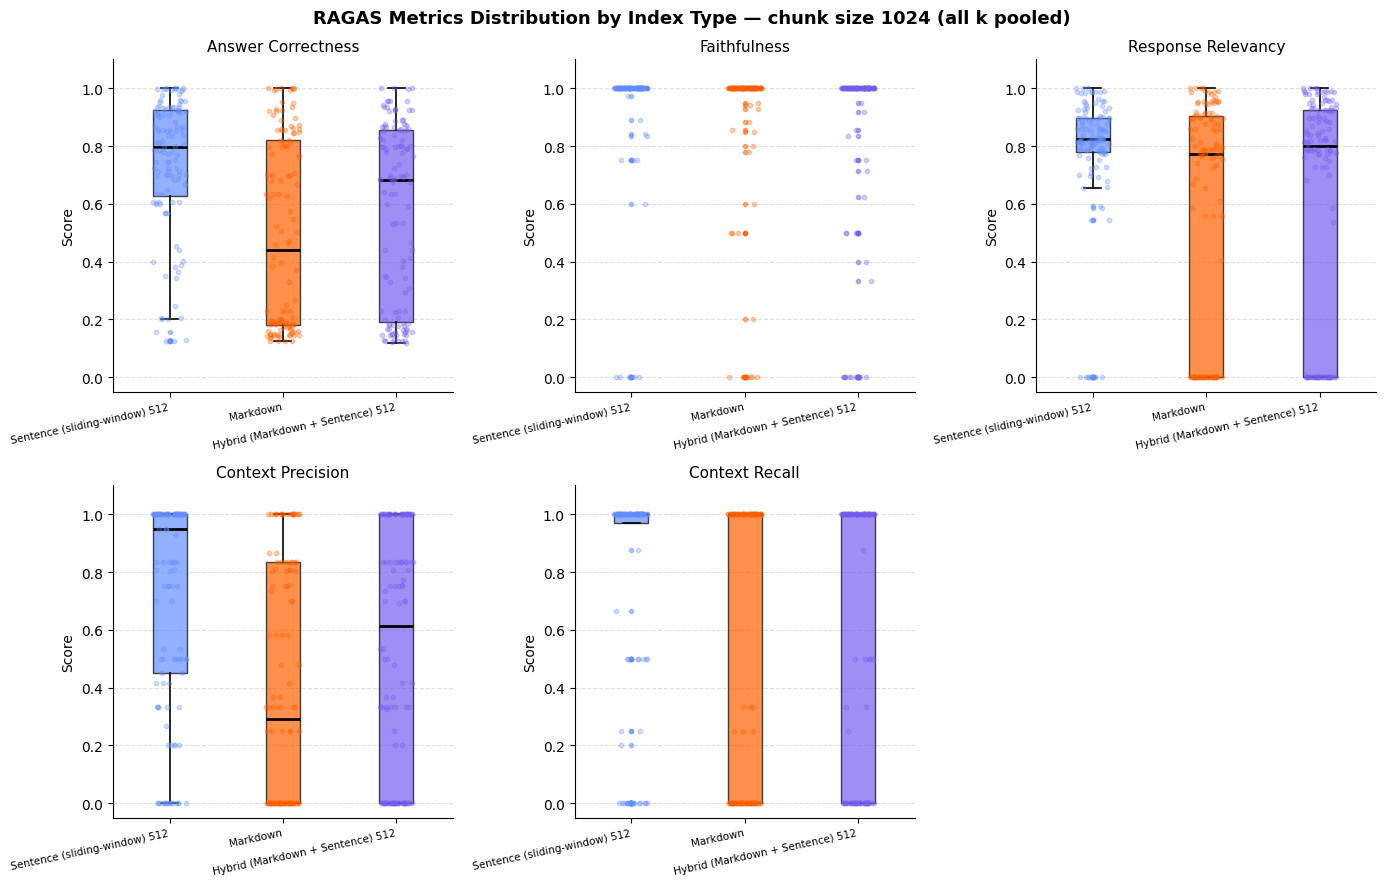

Saved: plots/3_metrics_boxplots.png


In [21]:
# ---------------------------------------------------------------------------
# Plot 3 — RAGAS metrics: box plots per index type (distribution across all k)
# ---------------------------------------------------------------------------
def plot_metrics_boxplots(df: pd.DataFrame, save_path: Path) -> None:
    available = [m for m in METRICS if m in df.columns]
    ncols = 3
    nrows = (len(available) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows), squeeze=False)
    fig.suptitle(
        "RAGAS Metrics Distribution by Index Type — chunk size 1024 (all k pooled)",
        fontsize=13, fontweight="bold",
    )

    for ax_idx, metric in enumerate(available):
        ax = axes[ax_idx // ncols][ax_idx % ncols]

        data   = [df[df["index_type"] == t][metric].dropna().values for t in INDEX_TYPES]
        labels = [INDEX_LABELS[t] for t in INDEX_TYPES]
        colors = [INDEX_COLORS[t] for t in INDEX_TYPES]

        bp = ax.boxplot(
            data,
            patch_artist=True,
            notch=False,
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            flierprops=dict(marker="o", markersize=3, linestyle="none", alpha=0.5),
        )

        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for flier, color in zip(bp["fliers"], colors):
            flier.set_markerfacecolor(color)
            flier.set_markeredgecolor(color)

        # overlay individual data points (jittered)
        for pos, (vals, color) in enumerate(zip(data, colors), start=1):
            jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(vals))
            ax.scatter(
                pos + jitter, vals,
                color=color, alpha=0.3, s=10, zorder=3,
            )

        ax.set_title(metric.replace("_", " ").title(), fontsize=11)
        ax.set_xticks(range(1, len(INDEX_TYPES) + 1))
        ax.set_xticklabels(labels, fontsize=7.5, rotation=12, ha="right")
        ax.set_ylabel("Score")
        ax.set_ylim(-0.05, 1.1)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    for ax_idx in range(len(available), nrows * ncols):
        axes[ax_idx // ncols][ax_idx % ncols].set_visible(False)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


plot_metrics_boxplots(df, PLOTS_DIR / "3_metrics_boxplots.png")

# NO ANSWARE: 1024

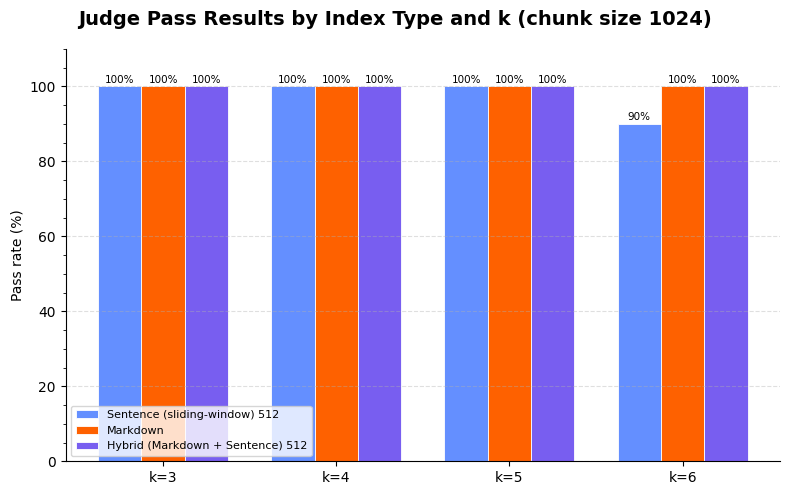

Saved: plots/1_pass_rate.png


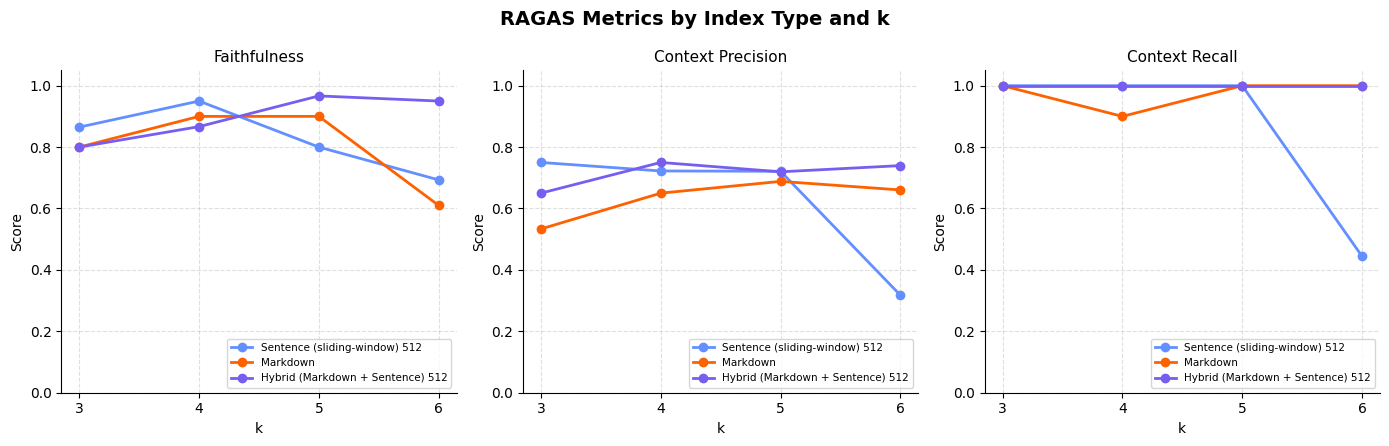

Saved: plots/2_metrics_lines.png


In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
RESULTS_DIR = Path("evals/experiments/no_answare")
PLOTS_DIR   = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

K_VALUES = [3, 4, 5, 6]
METRICS  = [
    "faithfulness",
    "context_precision",
    "context_recall",
]
INDEX_LABELS = {
    "sentence":              "Sentence (sliding-window) 512",
    "markdown":              "Markdown",
    "markdown_and_sentence": "Hybrid (Markdown + Sentence) 512",
}
INDEX_COLORS = {
    "sentence":              "#648FFF",
    "markdown":              "#FE6100",
    "markdown_and_sentence": "#785EF0",
}
INDEX_TYPES = list(INDEX_LABELS.keys())

# ---------------------------------------------------------------------------
# Data loading
# ---------------------------------------------------------------------------
def build_filename(index_type: str, k: int) -> Path:
    if index_type == "sentence":
        name = f"from_index_sentence_no_answare_1024_k_{k}_results.csv"
    elif index_type == "markdown":
        name = f"from_index_markdown_no_answare_k_{k}_results.csv"
    else:
        name = f"from_index_markdown_and_sentence_no_answare_1024_k_{k}_results.csv"
    return RESULTS_DIR / name


def load_all_results() -> pd.DataFrame:
    frames = []
    for index_type in INDEX_TYPES:
        for k in K_VALUES:
            path = build_filename(index_type, k)
            if not path.exists():
                print(f"[WARNING] File not found, skipping: {path}")
                continue
            df = pd.read_csv(path).dropna(subset=["question"])
            df["index_type"] = index_type
            df["k"]          = k
            frames.append(df)
    if not frames:
        raise FileNotFoundError(f"No CSVs found in '{RESULTS_DIR}'.")
    return pd.concat(frames, ignore_index=True)


def pass_stats(df: pd.DataFrame) -> pd.DataFrame:
    grp   = df.groupby(["index_type", "k"])
    stats = grp["judge_result"].apply(
        lambda s: (s.str.lower() == "pass").sum()
    ).rename("pass_count").reset_index()
    stats["total"]     = grp["judge_result"].count().values
    stats["pass_rate"] = stats["pass_count"] / stats["total"] * 100
    return stats


def metric_means(df: pd.DataFrame) -> pd.DataFrame:
    available = [m for m in METRICS if m in df.columns]
    return df.groupby(["index_type", "k"])[available].mean().reset_index()

df    = load_all_results()
stats = pass_stats(df)
means = metric_means(df)

# ---------------------------------------------------------------------------
# Plot 1 — Pass rate: grouped bar chart
# ---------------------------------------------------------------------------
def plot_pass_rate(stats: pd.DataFrame, save_path: Path) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.suptitle("Judge Pass Results by Index Type and k (chunk size 1024)", fontsize=14, fontweight="bold")

    bar_width = 0.25
    x = np.arange(len(K_VALUES))

    for i, idx_type in enumerate(INDEX_TYPES):
        subset = stats[stats["index_type"] == idx_type].sort_values("k")
        values = subset["pass_rate"].values
        bars = ax.bar(
            x + i * bar_width, values,
            width=bar_width,
            label=INDEX_LABELS[idx_type],
            color=INDEX_COLORS[idx_type],
            edgecolor="white", linewidth=0.6,
        )
        for bar, v in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{v:.0f}%",
                ha="center", va="bottom", fontsize=7.5,
            )

    ax.set_xticks(x + bar_width)
    ax.set_xticklabels([f"k={k}" for k in K_VALUES])
    ax.set_ylabel("Pass rate (%)")
    ax.set_ylim(0, 110)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


plot_pass_rate(stats, PLOTS_DIR / "1_pass_rate.png")

# ---------------------------------------------------------------------------
# Plot 2 — RAGAS metrics: line chart per metric
# ---------------------------------------------------------------------------
def plot_metrics_lines(means: pd.DataFrame, save_path: Path) -> None:
    available = [m for m in METRICS if m in means.columns]
    ncols = 3
    nrows = (len(available) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows), squeeze=False)
    fig.suptitle("RAGAS Metrics by Index Type and k", fontsize=14, fontweight="bold")

    for ax_idx, metric in enumerate(available):
        ax = axes[ax_idx // ncols][ax_idx % ncols]
        for idx_type in INDEX_TYPES:
            subset = means[means["index_type"] == idx_type].sort_values("k")
            ax.plot(
                subset["k"], subset[metric],
                marker="o", label=INDEX_LABELS[idx_type],
                color=INDEX_COLORS[idx_type], linewidth=2, markersize=6,
            )
        ax.set_title(metric.replace("_", " ").title(), fontsize=11)
        ax.set_xlabel("k")
        ax.set_ylabel("Score")
        ax.set_xticks(K_VALUES)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=7.5, loc="lower right")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(linestyle="--", alpha=0.4)

    for ax_idx in range(len(available), nrows * ncols):
        axes[ax_idx // ncols][ax_idx % ncols].set_visible(False)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


plot_metrics_lines(means, PLOTS_DIR / "2_metrics_lines.png")

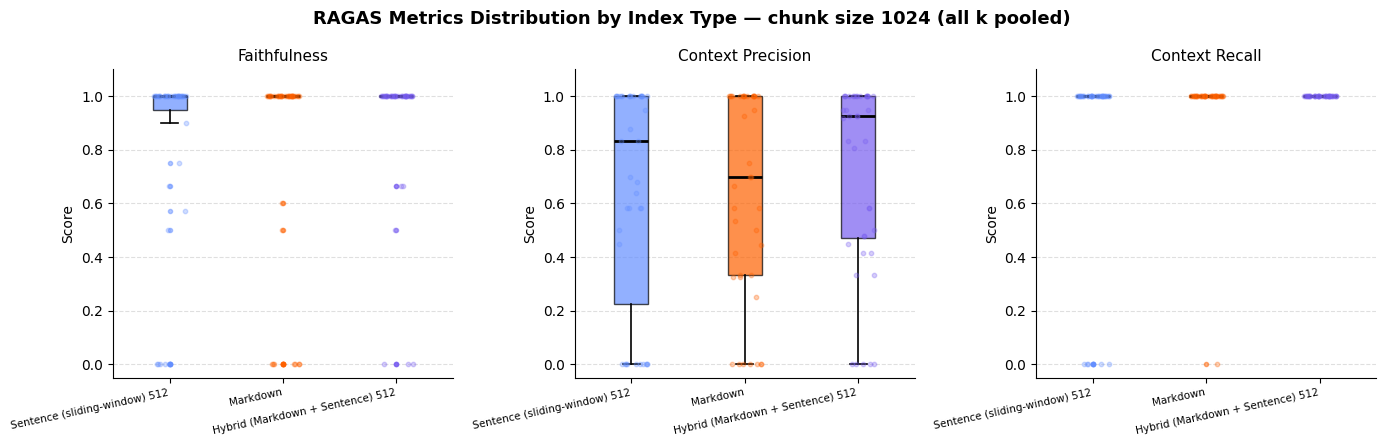

Saved: plots/3_metrics_boxplots.png


In [17]:
# ---------------------------------------------------------------------------
# Plot 3 — RAGAS metrics: box plots per index type (distribution across all k)
# ---------------------------------------------------------------------------
def plot_metrics_boxplots(df: pd.DataFrame, save_path: Path) -> None:
    available = [m for m in METRICS if m in df.columns]
    ncols = 3
    nrows = (len(available) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows), squeeze=False)
    fig.suptitle(
        "RAGAS Metrics Distribution by Index Type — chunk size 1024 (all k pooled)",
        fontsize=13, fontweight="bold",
    )

    for ax_idx, metric in enumerate(available):
        ax = axes[ax_idx // ncols][ax_idx % ncols]

        data   = [df[df["index_type"] == t][metric].dropna().values for t in INDEX_TYPES]
        labels = [INDEX_LABELS[t] for t in INDEX_TYPES]
        colors = [INDEX_COLORS[t] for t in INDEX_TYPES]

        bp = ax.boxplot(
            data,
            patch_artist=True,
            notch=False,
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            flierprops=dict(marker="o", markersize=3, linestyle="none", alpha=0.5),
        )

        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for flier, color in zip(bp["fliers"], colors):
            flier.set_markerfacecolor(color)
            flier.set_markeredgecolor(color)

        # overlay individual data points (jittered)
        for pos, (vals, color) in enumerate(zip(data, colors), start=1):
            jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(vals))
            ax.scatter(
                pos + jitter, vals,
                color=color, alpha=0.3, s=10, zorder=3,
            )

        ax.set_title(metric.replace("_", " ").title(), fontsize=11)
        ax.set_xticks(range(1, len(INDEX_TYPES) + 1))
        ax.set_xticklabels(labels, fontsize=7.5, rotation=12, ha="right")
        ax.set_ylabel("Score")
        ax.set_ylim(-0.05, 1.1)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    for ax_idx in range(len(available), nrows * ncols):
        axes[ax_idx // ncols][ax_idx % ncols].set_visible(False)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


plot_metrics_boxplots(df, PLOTS_DIR / "3_metrics_boxplots.png")

# My chatbot vs PERPLEXITY

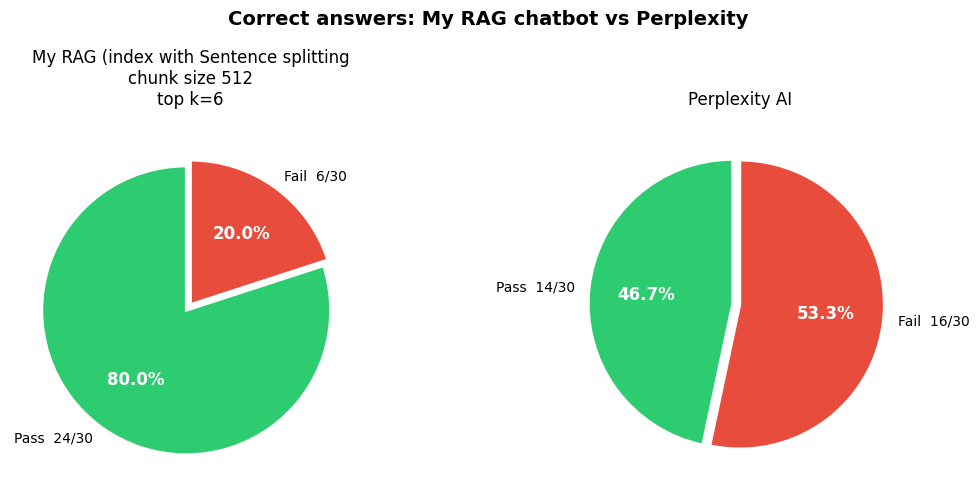

Saved: plots/5_pie_rag_vs_perplexity.png


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

PIE_PASS_COLOR = "#2ecc71"
PIE_FAIL_COLOR = "#e74c3c"

def _pie_counts(path: Path) -> tuple[int, int]:
    df_tmp = pd.read_csv(path).dropna(subset=["question"])
    passes = int((df_tmp["judge_result"].str.lower() == "pass").sum())
    return passes, len(df_tmp) - passes


def plot_pie_comparison(save_path: Path) -> None:
    path_rag = Path("evals/experiments/from_index_sentence_512_k_6_results.csv")
    path_prx = Path("evals/experiments/perplexity_results.csv")

    rag_pass, rag_fail = _pie_counts(path_rag)
    prx_pass, prx_fail = _pie_counts(path_prx)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
    fig.suptitle(
        "Correct answers: My RAG chatbot vs Perplexity",
        fontsize=14, fontweight="bold",
    )

    for ax, (n_pass, n_fail), title in [
        (ax1, (rag_pass, rag_fail), "My RAG (index with Sentence splitting\nchunk size 512\ntop k=6"),
        (ax2, (prx_pass, prx_fail), "Perplexity AI"),
    ]:
        total   = n_pass + n_fail
        sizes   = [n_pass, n_fail]
        labels  = [f"Pass  {n_pass}/{total}", f"Fail  {n_fail}/{total}"]
        colors  = [PIE_PASS_COLOR, PIE_FAIL_COLOR]
        explode = (0.05, 0)

        wedges, texts, autotexts = ax.pie(
            sizes,
            labels=labels,
            colors=colors,
            explode=explode,
            autopct="%1.1f%%",
            startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2),
            textprops=dict(fontsize=10),
        )
        for at in autotexts:
            at.set_fontsize(12)
            at.set_fontweight("bold")
            at.set_color("white")

        ax.set_title(title, fontsize=12, pad=14)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


plot_pie_comparison(PLOTS_DIR / "5_pie_rag_vs_perplexity.png")